# Assignment 5: Data Visualization
```
Course: ENV 700 - Environmental Data Exploration
Author: Student Name
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Visualization**, the third/fourth stage in the data analytics pipeline: **exploration, wrangling, analysis, and visualization**.

In this notebook, you will be working with two datasets: the Peter/Paul Northern Lakes Chemistry & Nutrients processed dataset, and the NEON Niwot Litter Mass Trap dataset. Specifically, we will be visualizing various aspects and relationships among the variable in these datasets. 

As always, address the tasks below to the best of your ability. Be sure to ask if any question is ambigious or unclear. When complete. Export your notebook into an HTML formatted document. Also, stage, commit, and push your assignment to your GitHub repository. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1.2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [1]:
# 1.1 Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import calendar

In [2]:
# 1.2 Paths 
project_fldr = Path.cwd().parent
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'Processed_Key'

#### 2. Ingest Data & Wrangle
* 2.1 NTL LTER data for Peter and Paul Lakes
    - Read the `'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv'` file into a dataframe. 
    - Convert the `sampledate` column to a datetime object.
    - Create a `month_abb` column to be an ordered categorical data type with levels for all months.
    - Display the first 5 records of the dataframe
* 2.2 NEON NIWO Litter Mass Trap Data (processed)
    - Read in the `NEON_NIWO_Litter_mass_trap_Processed.csv` file into a dataframe.
    - Convert the `collectDate` column to a datatime object.
    - Create a `year` column from the `collectDate` column 
    - Display the first 5 records of the dataframe

In [3]:
# 2.1.1 Import the NTL_LTER dataset as a dataframe, converting the sampledate field to a datetime object
NTL_LTER = (
    pd.read_csv(
        processed_fldr/'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
        parse_dates=['sampledate']
    )
)

In [4]:
# 2.1.2 Create a month column to be an ordered categorical data type with levels for all months.
NTL_LTER['month_abb'] = pd.Categorical(
    values=NTL_LTER['sampledate'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:],
)

In [5]:
# 2.1.3 Display the first 5 records of the dataframe
NTL_LTER.head()

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4,month_abb
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
2,Paul Lake,1984,148,5,1984-05-27,0.50,NaN,NaN,1150.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
3,Paul Lake,1984,148,5,1984-05-27,0.75,NaN,NaN,975.0,1620.0,NaN,NaN,NaN,NaN,NaN,May
4,Paul Lake,1984,148,5,1984-05-27,1.00,14.5,8.8,870.0,1620.0,NaN,NaN,NaN,NaN,NaN,May


In [6]:
# 2.2.1 Import the NEON NIWO dataset, setting the `collectDate` field to a datetime object
NEON_NIWO = (
    pd.read_csv(
        processed_fldr/'NEON_NIWO_Litter_mass_trap_Processed.csv',
        parse_dates=['collectDate']
    )
)

In [7]:
# 2.2.2 Create a year column from the `collectDate` field.
NEON_NIWO['year'] = pd.Categorical(
    values=NEON_NIWO['collectDate'].dt.year
)

In [8]:
# 2.2.3 Display the first 5 records of the dataframe
NEON_NIWO.head()

,plotID,trapID,collectDate,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum,year
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84,2016
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84,2016
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84,2016


#### 3. Set your Seaborn Theme
* Choose a Seaborn theme; set its context to what you feel is appropriate for this notebook
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set the theme's runtime configuration (`rc`) so that plots have a *title size* of 20 and use a serif *font family*.

In [9]:
#3. Set the seaborn theme
# Set the default theme attributes
sns.set_theme(style='whitegrid',
              palette='colorblind',
              context='notebook',
              font_scale= 0.8,
              rc= {'font.family': 'serif',
                   'figure.titlesize': 20
                   }
            )

#### 4. Relationship of Total Phosphorous to Phosphate
Total Phosphorus (TP) measures every form of phosphorus in a lake, while phosphate (orthophosphate or PO₄) is the specific, dissolved, inorganic fraction that algae can directly absorb. We might therefore expect PO₄ to increase with increases in TP; we want to confirm that expectation with a visualization of our data. 
- Create a scatterplot of PO₄ as a function of TP (assign TP to the x-axis), using separate aesthetics to differientiate the two (Peter and Paul) lakes.
- Adjust your axes to hide extreme values. (Hint: change the limits using `xlim()` and `ylim()`).
- If your plot as many overlapping points, consider making the point features semi-transparent.
- Ensure your plot has an appropriate title, axis labels, and other stylistic features to make it look tidy and professional. 

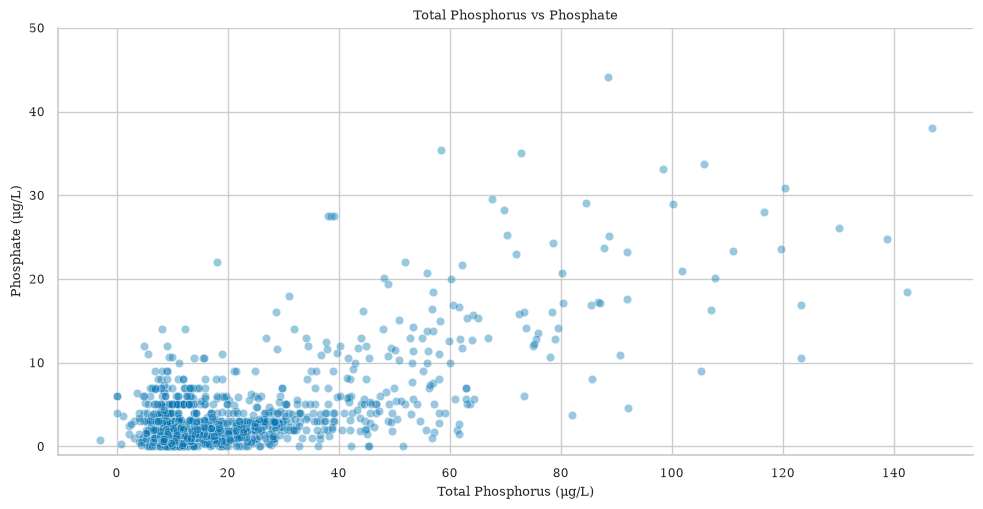

In [10]:
# 4. Create a scatterplot of PO4 vs TP
g = sns.relplot(
    data=NTL_LTER,
    x="tp_ug",
    y="po4",
    aspect=2,
    alpha= 0.4
);

#Set properties of the plot object
g.set(
    title  = 'Total Phosphorus vs Phosphate',
    xlabel = 'Total Phosphorus (\N{Greek small letter mu}g/L)',
    ylabel = 'Phosphate (\u03BCg/L)',
    ylim= (-1, 50),
);

#### 4-Challenge
* Re-construct your plot so that it includes a regression line (hint: `lmplot()`)
* Note that for the regression line to exclude extreme values, you'll have to filter the dataframe used in the plot; setting the x and y limits won't do that for you. 

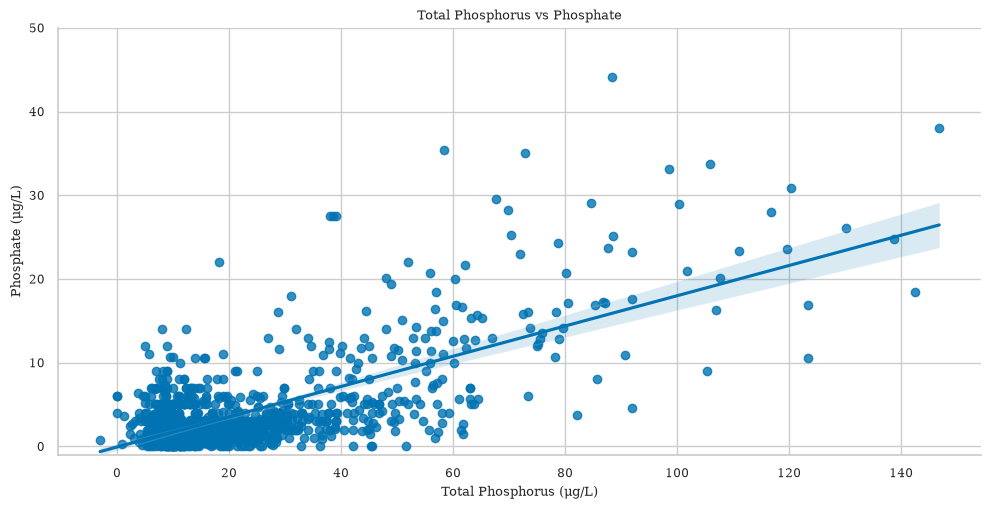

In [11]:
# 4-challenge
NTL_LTER_filtered = NTL_LTER.loc[NTL_LTER['po4'] < 50]

g = sns.lmplot(
    data=NTL_LTER_filtered,
    x="tp_ug",
    y="po4",
    aspect=2,
);

#Set properties of the plot object
g.set(
    title  = 'Total Phosphorus vs Phosphate',
    xlabel = 'Total Phosphorus (\N{Greek small letter mu}g/L)',
    ylabel = 'Phosphate (\u03BCg/L)',
    ylim= (-1, 50),

);

### 5. Comparison of monthly trends of select variables across lakes
We are interested in comparing monthly trends in three lake variables: Total Nitrogren, Total Phosphorus, and Temperature, contrasting differences among the two lakes.
* 5.1 First, you'll need to "melt" your data so that all temperature, TP, and TN measures appear in a single column alongside a separate column that lists whether the row is temperature, TN, or TP record.
* 5.2 Construct a box plot of the 3 lake measurements such that
    - Months appear along the x-axis
    - Peter and Paul lake data are shown in different colors
    - The plots for temperature, TN, and TP are shown as separate facets, stacked vertically, and each have their own y-axis scale (hint: `sharey=False`).
    - Remove the individual plot titles and x-axis labels (hint: set to an empty string `""`).
    - Set the y-axis labels to indicate the plots of Temperature, Total Nitrogen, and Total Phosphorus. 

In [12]:
# 5.1 Melt the NTL LTR dataset so that Temperature, TN, and TP measures are consolidated in a single column
NTL_LTER_melted = NTL_LTER.melt(
    id_vars=['lakename','month_abb', 'sampledate'],
    value_vars=["temperature_C", "tn_ug", "tp_ug"],
    var_name="measurement",
    value_name="value"
)

NTL_LTER_melted.head(15)

,lakename,month_abb,sampledate,measurement,value
0,Paul Lake,May,1984-05-27,temperature_C,14.5
1,Paul Lake,May,1984-05-27,temperature_C,NaN
2,Paul Lake,May,1984-05-27,temperature_C,NaN
3,Paul Lake,May,1984-05-27,temperature_C,NaN
4,Paul Lake,May,1984-05-27,temperature_C,14.5
5,Paul Lake,May,1984-05-27,temperature_C,NaN
6,Paul Lake,May,1984-05-27,temperature_C,14.2
7,Paul Lake,May,1984-05-27,temperature_C,11.0
8,Paul Lake,May,1984-05-27,temperature_C,7.0
9,Paul Lake,May,1984-05-27,temperature_C,6.1


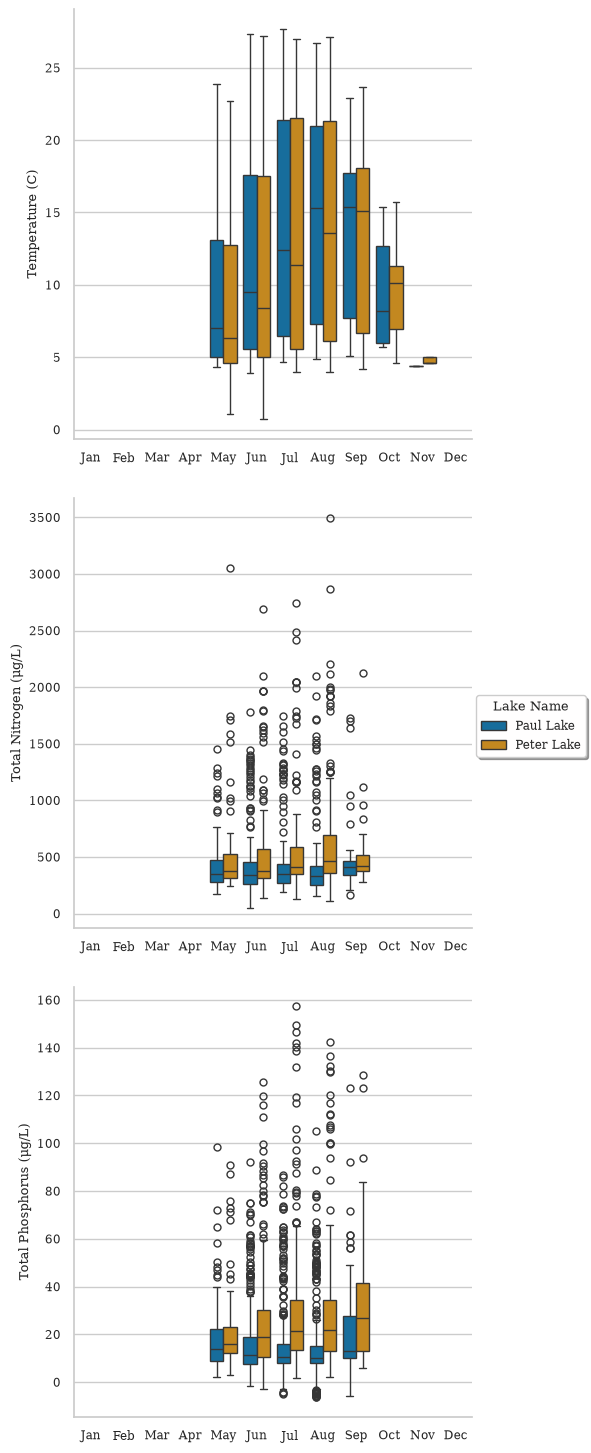

In [13]:
# 5.2 Create the faceted plot
g = sns.catplot(
    data=NTL_LTER_melted,
    x='month_abb',
    y='value',
    hue='lakename',
    kind='box',
    col='measurement',
    col_wrap=1,
    sharey=False,
    sharex=False
);

# 5.3 Style the plot

g.axes[0].set(
    title = '',
    xlabel= '',
    ylabel= 'Temperature (C)'
    )
g.axes[1].set(
    title = '',
    xlabel= '',
    ylabel= 'Total Nitrogen (\N{Greek small letter mu}g/L)'
    )
g.axes[2].set(
    title = '',
    xlabel= '',
    ylabel= 'Total Phosphorus (\N{Greek small letter mu}g/L)'
    )
# 5.4 Set the legend
sns.move_legend(
    g, 
    loc='right', #Switch to "upper left"
    title='Lake Name',
    facecolor="#FFFEFE",
    shadow=True,
    frameon=True
)

#### ✅ Question
**What do you observe about the variables of interest over seasons and between lakes?**
> **Answer**:  
>  Both Nitrogren and phophorous levels are higher on average in Peter lake than Paul lake year round. Both these nutrients peak in the summer and early Fall. Temperature seems to be most variable as well as highest on average in the summer.

### 6. Dry mass of needles over time
We are curious how the amount of needles is changing from year to year, specifically how those trends might appear across different land cover types. To do that we'll explore a few visualizations. 

#### 6.1 Change in needle dry mass over time, single plot
* Plot a subset of the litter dataset by displaying only the "Needles" functional group in a single plot figure. 
* Plot the dry mass of needle litter by year, separating by NLCD class with a color aesthetic. (no need to adjust the name of each land use)
* Treat the years as categorical data in your selection of `displot()`, `catplot()`, or `relplot()` plotting functions. 
* Select a plotting function subplot type (e.g. "scatterplot" for relplot, "swarmplot" for catplot) that you feel best illustrates change over time of the needle dry mass from year to year to year for the different land cover types.
* Style your plot for professionalism and clarity.  Specifically:
    - Give your plot a title.
    - Label axes appropriately. ("Year" is an optional label, as it can be considered obvious.)
    - Title and place your legend to maximize clarity.
    - Ensure that your font sizes are appropriate. (Hint: adjust plot height and aspect.)
    - *You can use default cover type names, e.g. `shrubScrub`.*

In [14]:
NEON_NIWO.head()

,plotID,trapID,collectDate,functionalGroup,dryMass,qaDryMass,subplotID,decimalLatitude,decimalLongitude,elevation,nlcdClass,plotType,geodeticDatum,year
0,NIWO_062,NIWO_062_050,2016-06-16,Seeds,0.00,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
1,NIWO_061,NIWO_061_169,2016-06-16,Other,0.27,N,41,40.047615,-105.586103,3413.4,evergreenForest,tower,WGS84,2016
2,NIWO_062,NIWO_062_050,2016-06-16,Woody material,0.12,N,31,40.051140,-105.585787,3477.0,shrubScrub,tower,WGS84,2016
3,NIWO_064,NIWO_064_103,2016-06-16,Seeds,0.00,N,32,40.047370,-105.583997,3373.2,evergreenForest,tower,WGS84,2016
4,NIWO_058,NIWO_058_101,2016-06-16,Needles,1.11,Y,32,40.048719,-105.587181,3446.4,shrubScrub,tower,WGS84,2016


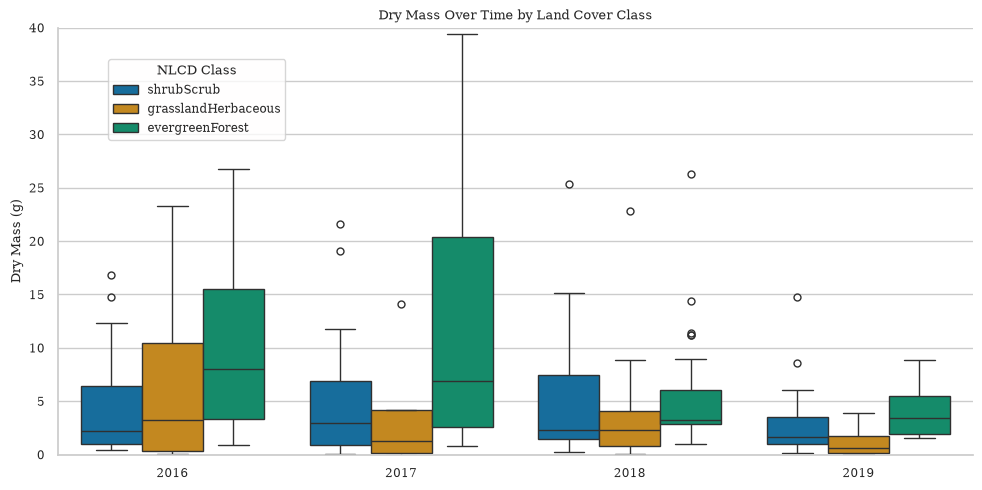

In [15]:
# 6. Plot the dry mass of needles over time, separated by NLCD cover type
NEON_needles = NEON_NIWO.loc[
    NEON_NIWO['functionalGroup'] == 'Needles'
]
g = sns.catplot(
    data=NEON_needles,
    x='year',
    y='dryMass',
    kind='box',
    hue='nlcdClass',
    aspect=2
);
g.set(
    title = 'Dry Mass Over Time by Land Cover Class',
    xlabel= '',
    ylabel= 'Dry Mass (g)',
    ylim=(0,40)
    )

sns.move_legend(
    g,
    loc='upper left', 
    title='NLCD Class',
    facecolor="#FFFEFE",
    bbox_to_anchor=(0.1,0.92),
    frameon=True
);

#### 6.2 Change in needle dry mass over time, facet plot
* Recreate your plot above, but instead of a single plot, break your plot into 3 facets: one for each cover type. 
* You are welcome to explore different plot subtypes than the previous plot. 
* Decide whether you want to stack the facet plots vertically or horizontally based on how well it communicates differences in the trends and magnitude of leaf litter change over time across the different cover types. 
* As before, style your plot for professionalism and clarity. 

[Text(0.5, 1.0, ''),
 Text(0.5, 8.844444444444497, ''),
 Text(12.844444444444457, 0.5, 'evergreenForest Dry Mass (g)'),
 (0.0, 40.0)]

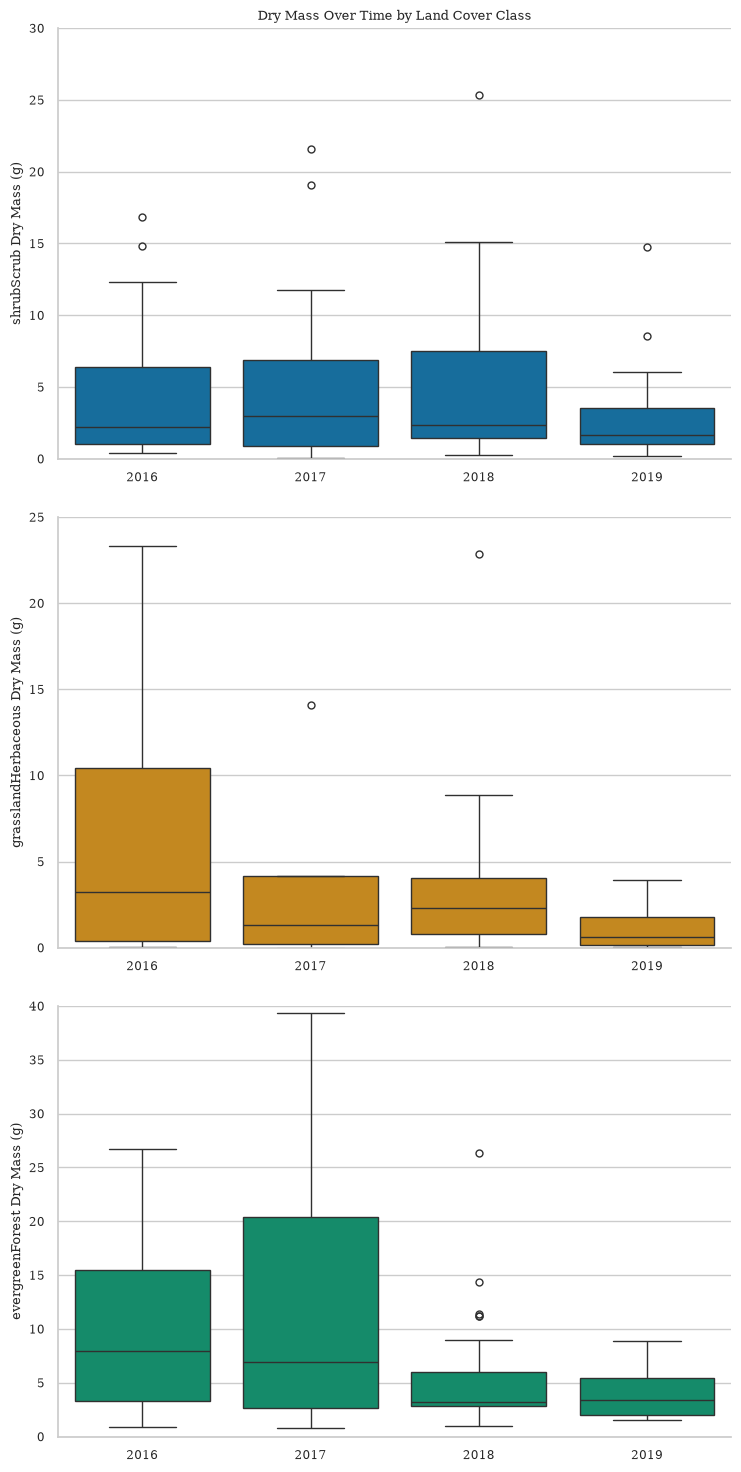

In [16]:
# 6.2 Plot the dry mass of needles over time, faceted by NLCD cover type
NEON_needles = NEON_NIWO.loc[
    NEON_NIWO['functionalGroup'] == 'Needles'
]
g = sns.catplot(
    data=NEON_needles,
    x='year',
    y='dryMass',
    kind='box',
    aspect=1.5,
    col='nlcdClass',
    hue='nlcdClass',
    col_wrap=1,
    sharey=False,
    sharex=False,
    legend=False
);
g.axes[0].set(
    title = 'Dry Mass Over Time by Land Cover Class',
    xlabel= '',
    ylabel= 'shrubScrub Dry Mass (g)',
    ylim=(0,30)
    );
g.axes[1].set(
    title = '',
    xlabel= '',
    ylabel= 'grasslandHerbaceous Dry Mass (g)',
    ylim=(0,25)
    )
g.axes[2].set(
    title = '',
    xlabel= '',
    ylabel= 'evergreenForest Dry Mass (g)',
    ylim=(0,40)
    )


#### ✅ Question
**Which of the two plots do you feel better reveals the pattern of needle dry mass over time? Why?**
> **Answer**:  
>  I actually like the first plot better. It is easier to simultaneously compare dry mass change across time within and between land cover types. Having it all horizontally like that makes it more straightforward to read trends from..


#### ✅ Question
**Explain your choice of subplot in the plots above. What aspects of that subplot type led to your choice.**
> **Answer**:  
>  I chose the boxplot for a couple reasons. On a basic level, it is a great choice for any numerical and categorical data combination. Additionally, it lends itself well to the dataset used here as it shows a bit more complexity to the data than if we just plotted mean dry mass for each year in a scatter plot. It's also just a little easier to understand here than a swarm plot.